In [ ]:
import sys
from pathlib import Path

# Find project root dynamically
def get_project_root() -> Path:
    try:
        path = Path(__file__).resolve()
        for parent in [path] + list(path.parents):
            if (parent / "requirements.txt").exists() or (parent / "project").exists():
                return parent
    except NameError:
        pass
    path = Path.cwd().resolve()
    for parent in [path] + list(path.parents):
        if (parent / "requirements.txt").exists() or (parent / "project").exists():
            return parent
    return path

ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torch.nn as nn
from torch.nn import functional as F

In [ ]:
# Step 13: Create dummy query and context tensors

# x = query sequence
# Shape: (batch_size, query_length, embedding_dim)
x = torch.randn(2, 10, 64)

# context = keys/values sequence
# Shape: (batch_size, context_length, embedding_dim)
context = torch.randn(2, 5, 64)

print("x shape:", x.shape)
print("context shape:", context.shape)

context[0, 2] = x[0, 5]

x shape: torch.Size([2, 10, 64])
context shape: torch.Size([2, 5, 64])


In [ ]:
class CrossAttentionHead(nn.Module):

    def __init__(self, n_embd, head_size):

        super().__init__()

        # Queries, Keys and Values projections
        self.query = nn.Linear(n_embd, head_size, bias=False)

        self.key = nn.Linear(n_embd, head_size, bias=False)

        self.value = nn.Linear(n_embd,head_size,bias=False)

    def forward(self, x, context):

        # x       : (B, T_x, C)
        # context : (B, T_c, C)

        # x.shape = (2, 10, 64)
        # context.shape = (2, 5, 64)
        # head_size = 16

        # Queries come from x - (2, 10, 16)
        q = self.query(x)

        # Keys and Values come from context - (2, 5, 16)
        k = self.key(context)
        v = self.value(context)

        # Attention scores - (2, 10, 5)
        wei = q @ k.transpose(-2, -1)

        # Scale scores
        wei = wei * (k.size(-1) ** -0.5)

        # Convert to probabilities
        wei = F.softmax(wei, dim=-1)

        # Save for visualization
        self.attention_weights = wei

        # No causal mask in cross-attention

        # Weighted aggregation of values - (2, 10, 16)
        out = wei @ v

        return out

In [ ]:
# MULTI HEAD ATTENTION
# multiple attention heads running in parallel
class MultiHeadCrossAttention(nn.Module):

    def __init__(self, num_heads, head_size, n_embd):

        super().__init__()

        # create multiple independent attention heads
        self.heads = nn.ModuleList([
          CrossAttentionHead(n_embd, head_size)
          for _ in range(num_heads)
        ])

        # projection layer
        # mixes information from all heads together
        self.proj = nn.Linear(
            num_heads * head_size,
            n_embd
        )

    def forward(self, x, context):

        # run all heads independently
        # concatenate outputs along feature dimension
        out = torch.cat(
            [h(x, context) for h in self.heads],
            dim=-1
        )

        # projection layer
        out = self.proj(out)


        return out

In [ ]:
cross_attn = MultiHeadCrossAttention(
    num_heads=4,
    head_size=16,
    n_embd=64
)

out = cross_attn(x, context)

attn = cross_attn.heads[0].attention_weights


In [ ]:
print(attn[0, 5])

tensor([0.1951, 0.1923, 0.2020, 0.2012, 0.2093], grad_fn=<SelectBackward0>)


In [ ]:
optimizer = torch.optim.Adam(
    cross_attn.parameters(),
    lr=1e-2
)

In [ ]:
for step in range(1000):

    out = cross_attn(x, context)

    # Get current attention weights
    attn = cross_attn.heads[0].attention_weights

    # Encourage query position 5 to attend to context position 2
    loss = -torch.log(
        attn[0,5,2] + 1e-8
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(
            f"step {step}: "
            f"loss={loss.item():.6f}, "
            f"attn={attn[0,5,2].item():.4f}"
        )

step 0: loss=1.599357, attn=0.2020
step 100: loss=-0.000000, attn=1.0000
step 200: loss=-0.000000, attn=1.0000
step 300: loss=-0.000000, attn=1.0000
step 400: loss=-0.000000, attn=1.0000
step 500: loss=-0.000000, attn=1.0000
step 600: loss=-0.000000, attn=1.0000
step 700: loss=-0.000000, attn=1.0000
step 800: loss=-0.000000, attn=1.0000
step 900: loss=-0.000000, attn=1.0000


In [ ]:
attn = cross_attn.heads[0].attention_weights

print(attn[0,5])

tensor([1.0861e-24, 7.0977e-23, 1.0000e+00, 1.8185e-23, 5.9121e-22],
       grad_fn=<SelectBackward0>)


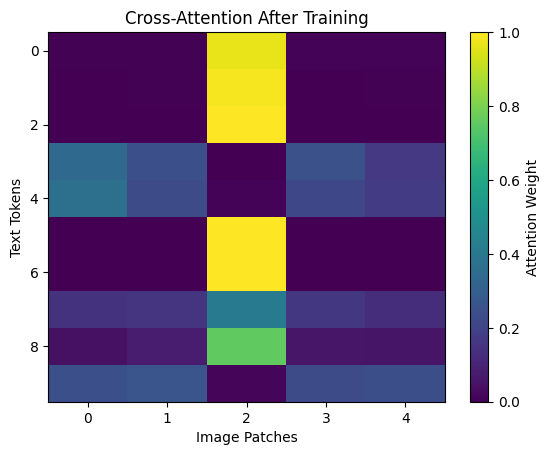

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(
    attn[0].detach().numpy(),
    aspect='auto'
)

plt.xlabel("Image Patches")
plt.ylabel("Text Tokens")
plt.colorbar(label="Attention Weight")
plt.title("Cross-Attention After Training")
plt.show()

For Step 16, a structured experiment was performed to verify that the cross-attention mechanism can learn to route information from a specific context position to a specific query position.

The vector at context[0,2] was made identical to x[0,5], and a training objective was used to encourage query position 5 to focus on context position 2.

Before training, the attention distribution was relatively random and did not strongly favor the target context position. After optimization, the attention heatmap showed a clear concentration of attention on context position 2, demonstrating that the cross-attention layer successfully learned the desired routing behavior.
